In [1]:
import sys
sys.path.append('../')
sys.path.append('../../')
import pydicom
from IPython.display import clear_output
import time
import math
from IPython.display import clear_output
from pydicom.data import get_testdata_file
from pydose_rt import ModelConfig
# from pydose_rt import ModelConfig
import numpy as np
from rt_utils import RTStructBuilder
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, rotate
from pydose_rt import DoseEngine
from pydose_rt.utils.data_loading import load_rtp_data
from skimage import measure
import SimpleITK as sitk
import torch

In [2]:
roi_colors = {
    "PTV": "orange",
    "ROI1": "red",
    "ROI2": "green",
    "ROI3": "blue",
    "ROI4": "purple",
    "ROI5": "brown",
    "ROI6": "black",
}

def overlay_mask_outline(mask_slice, color="red", linewidth=1):
    for contour in measure.find_contours(mask_slice, 0.5):
        plt.plot(contour[:, 1], contour[:, 0], color=color, linewidth=linewidth)


In [3]:
# Set paths
ct_folder = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21/"
rtplan_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21_plans/1ARC/RP1.2.752.243.1.1.20251031145134399.7000.37887.dcm"
rtdose_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21_plans/1ARC/RD1.2.752.243.1.1.20251031145134399.8000.21005.dcm"
# Load CT

ct_image, doses, masks, mlc_inputs = load_rtp_data(ct_folder, dose_path=[rtdose_path], plan_path=[rtplan_path], scaling=400)
dose_volume = sitk.GetArrayFromImage(doses['dose_0'])
ct_volume = sitk.GetArrayFromImage(ct_image)
external_mask = sitk.GetArrayFromImage(masks["External"])
ct_volume = np.where(external_mask, ct_volume, -1000.0)

In [4]:
from scipy.ndimage import measurements
measurements.center_of_mass(sitk.GetArrayFromImage(masks["PTVT_42.7"]))

/tmp/ipykernel_1094671/3722899455.py:2: DeprecationWarning: Please import `center_of_mass` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  measurements.center_of_mass(sitk.GetArrayFromImage(masks["PTVT_42.7"]))


(84.28809928344538, 94.02903154317795, 93.97133781487774)

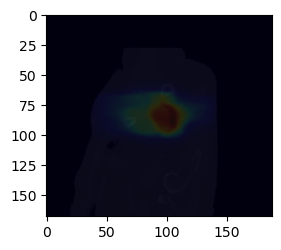

In [5]:
plt.subplot(121)
plt.imshow(ct_volume[:, :, 110], cmap='gray')
plt.imshow(dose_volume[:, :, 110], cmap='jet', alpha=0.6)
plt.imshow(sitk.GetArrayFromImage(masks["CTV"])[:, :, 110], cmap='gray', alpha=0.8)

[2.0, 2.0, 2.0]
(168, 188, 188)


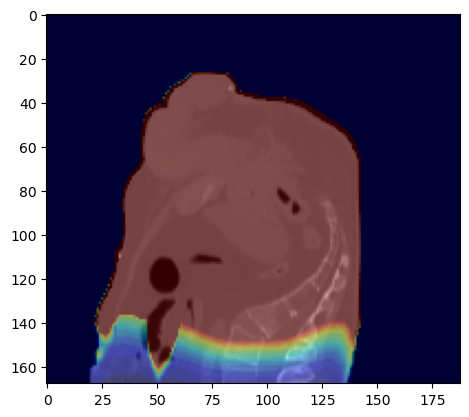

In [6]:
ct_spacing = [ct_image.GetSpacing()[0], ct_image.GetSpacing()[1], ct_image.GetSpacing()[2]]
ct_shape = ct_volume.shape

print(ct_spacing)
print(ct_shape)
plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2], alpha=0.4, cmap='jet', vmax=0.01)

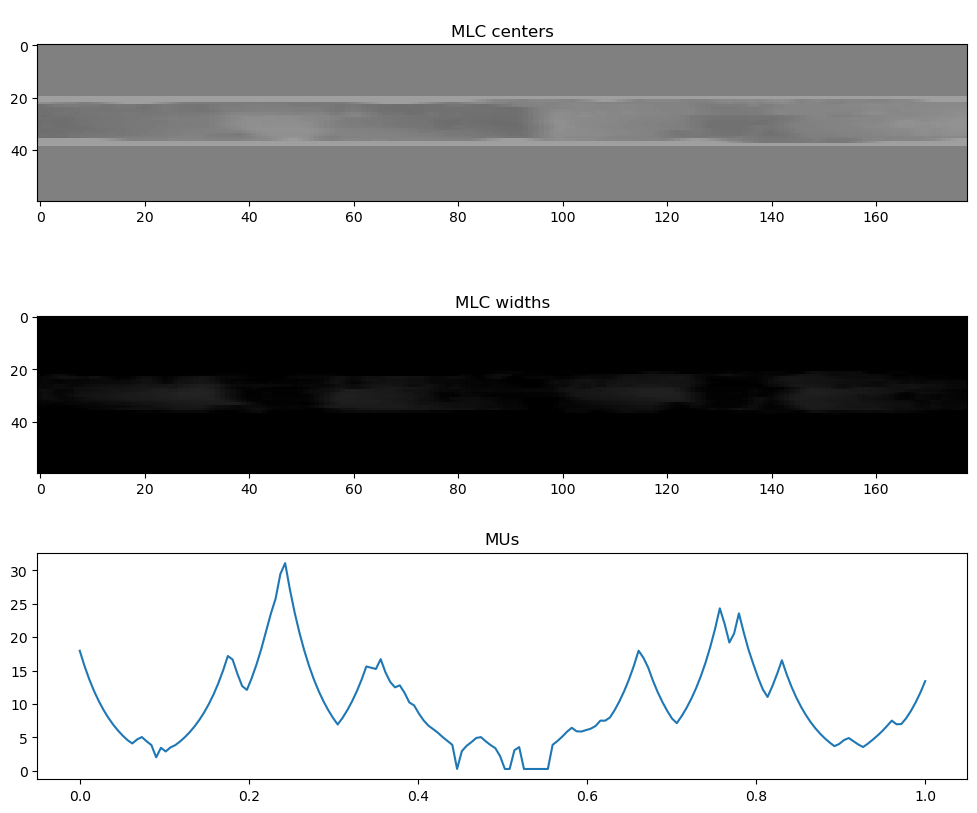

In [7]:
ct_slices = np.array(np.expand_dims(ct_volume, 0), dtype=np.float32)
leafs_1, mus_1 = mlc_inputs[0]
plt.figure(figsize=(12, 10))
plt.axis('off')
plt.subplot(311)
plt.title('MLC centers')
plt.imshow(np.transpose(torch.tensor(np.array(leafs_1), dtype=torch.float32, device='cuda').cpu().detach().numpy()[0, 0, :, :]), cmap='gray', vmin=0, vmax=1, aspect=0.5, interpolation='none')
plt.subplot(312)
plt.title('MLC widths')
plt.imshow(np.transpose(torch.tensor(np.array(leafs_1), dtype=torch.float32, device='cuda').cpu().detach().numpy()[0, 1, :, :]), cmap='gray', vmin=0, vmax=1, aspect=0.5, interpolation='none')
plt.subplot(313)
plt.title('MUs')
plt.plot(np.linspace(0, 1, 178), torch.tensor(np.array(mus_1), dtype=torch.float32, device='cuda').cpu().detach().numpy()[0, :]) #, cmap='gray', aspect=10.0, interpolation='none')
plt.show()

In [ ]:
config_1 = ModelConfig(preset="umea",
                    ct_array_shape=ct_shape, 
                    resolution=ct_spacing, 
                    field_size=(400, 400), 
                    downsampling_factor=(1, 2, 2), 
                    number_of_cps=178, 
                    starting_angle=180.0,
                    tpr_20_10=0.74,
                    clockwise=True,
                    )
dose_layer_1 = DoseEngine(config_1, 55, permute_ct=False, leafs_centered=True)
jaws_1 = np.zeros(config_1.shape_jaws)
jaws_1[:, 0, :] = 0.5
jaws_1[:, 1, :] = 1.0
dose_1 = np.zeros_like(ct_slices)
for cp_idx in range(config_1.number_of_cps):
    dose, _ = dose_layer_1(torch.tensor(np.array(leafs_1), dtype=torch.float32, device='cuda'), 0.1*torch.tensor(np.array(mus_1), dtype=torch.float32, device='cuda'), torch.tensor(np.array(jaws_1), dtype=torch.float32, device='cuda'), ct_image=torch.tensor(ct_slices, dtype=torch.float32, device='cuda'), single_cp=cp_idx)
    dose_1 += dose.cpu().detach().numpy()

sag_slice = ct_shape[2] // 2
ax_slice = 71
cor_slice = ct_shape[1] // 2 + 2
dose_pred = dose_1
dose_pred = dose_pred
dose_pred = dose_pred * (np.quantile(dose_volume, 0.999) / np.quantile(dose_pred, 0.999))
ext_mask = sitk.GetArrayFromImage(masks["External"]) > 0
diff = ext_mask * np.abs(dose_volume - dose_pred)**2
print(np.mean(diff))

dose_plot = dose_pred
pred_max = np.max(dose_volume)
resampled_ct = ct_image
dose_max = np.max(dose_volume)
alpha = 0.3
plt.figure(figsize=(20, 30))
plt.subplot(321)
plt.imshow(ct_volume[:, :, sag_slice], cmap='gray')
plt.imshow(dose_volume[:, :, sag_slice], cmap='jet', vmax=dose_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(np.array(sitk.GetArrayFromImage(roi))[:, :, sag_slice], color=color)
plt.colorbar()
plt.subplot(322)
plt.imshow(ct_volume[:, :, sag_slice], cmap='gray')
plt.imshow(dose_plot[0, :, :, sag_slice], cmap='jet', vmax=pred_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(np.array(sitk.GetArrayFromImage(roi))[:, :, sag_slice], color=color)
plt.colorbar()
plt.subplot(323)
plt.imshow(ct_volume[:, cor_slice, :], cmap='gray')
plt.imshow(dose_volume[:, cor_slice, :], cmap='jet', vmax=dose_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(np.array(sitk.GetArrayFromImage(roi))[:, cor_slice, :], color=color)
plt.colorbar()
plt.subplot(324)
plt.imshow(ct_volume[:, cor_slice, :], cmap='gray')
plt.imshow(dose_plot[0, :, cor_slice, :], cmap='jet', vmax=pred_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(np.array(sitk.GetArrayFromImage(roi))[:, cor_slice, :], color=color)
plt.colorbar()
plt.subplot(325)
plt.imshow(ct_volume[ax_slice, :, :], cmap='gray')
plt.imshow(dose_volume[ax_slice, :, :], cmap='jet', vmax=dose_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(np.array(sitk.GetArrayFromImage(roi))[ax_slice, :, :], color=color)
plt.colorbar()
plt.subplot(326)
plt.imshow(ct_volume[ax_slice, :, :], cmap='gray')
plt.imshow(dose_plot[0, ax_slice, :, :], cmap='jet', vmax=pred_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(np.array(sitk.GetArrayFromImage(roi))[ax_slice, :, :], color=color)
plt.colorbar()
plt.show()

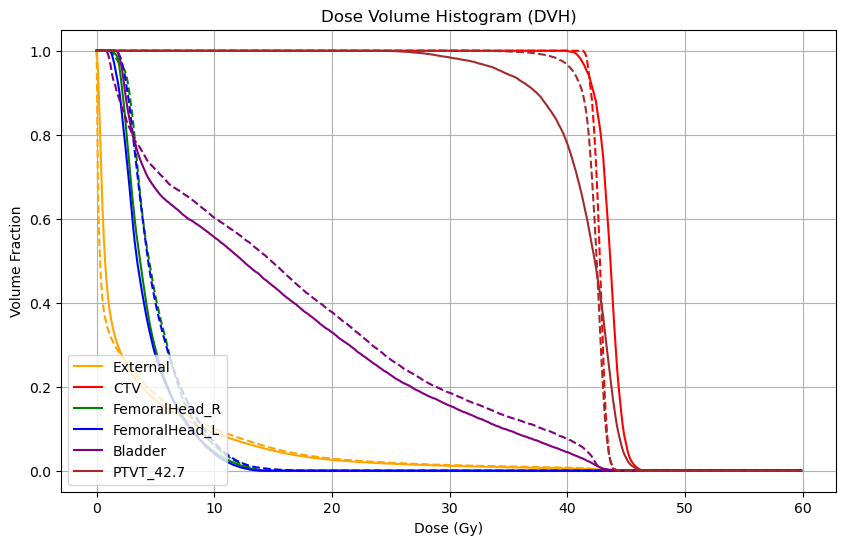

In [9]:
bins = np.linspace(0, 60.0, 500)


plt.figure(figsize=(10, 6))
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    dose_pred_hist = dose_pred[0][np.array(sitk.GetArrayFromImage(masks[roi_name]), dtype=np.bool_)]
    dose_gt = dose_volume[np.array(sitk.GetArrayFromImage(masks[roi_name]), dtype=np.bool_)]


    # Compute the histogram
    hist, bin_edges = np.histogram(dose_gt, bins=bins, density=False)
    cumulative_hist = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
    cumulative_hist_normalized = (
        cumulative_hist / cumulative_hist.max()
    )  # Normalize
    plt.plot(
        bin_edges[:-1],
        cumulative_hist_normalized,
        label=None,
        linestyle='--',
        color=color,
    )

    # Compute the histogram
    hist, bin_edges = np.histogram(dose_pred_hist, bins=bins, density=False)
    cumulative_hist = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
    cumulative_hist_normalized = (
        cumulative_hist / cumulative_hist.max()
    )  # Normalize
    plt.plot(
        bin_edges[:-1],
        cumulative_hist_normalized,
        label=roi_name,
        color=color,
    )

plt.xlabel("Dose (Gy)")
plt.ylabel("Volume Fraction")
plt.title("Dose Volume Histogram (DVH)")
plt.legend(loc='lower left')
plt.grid(True)

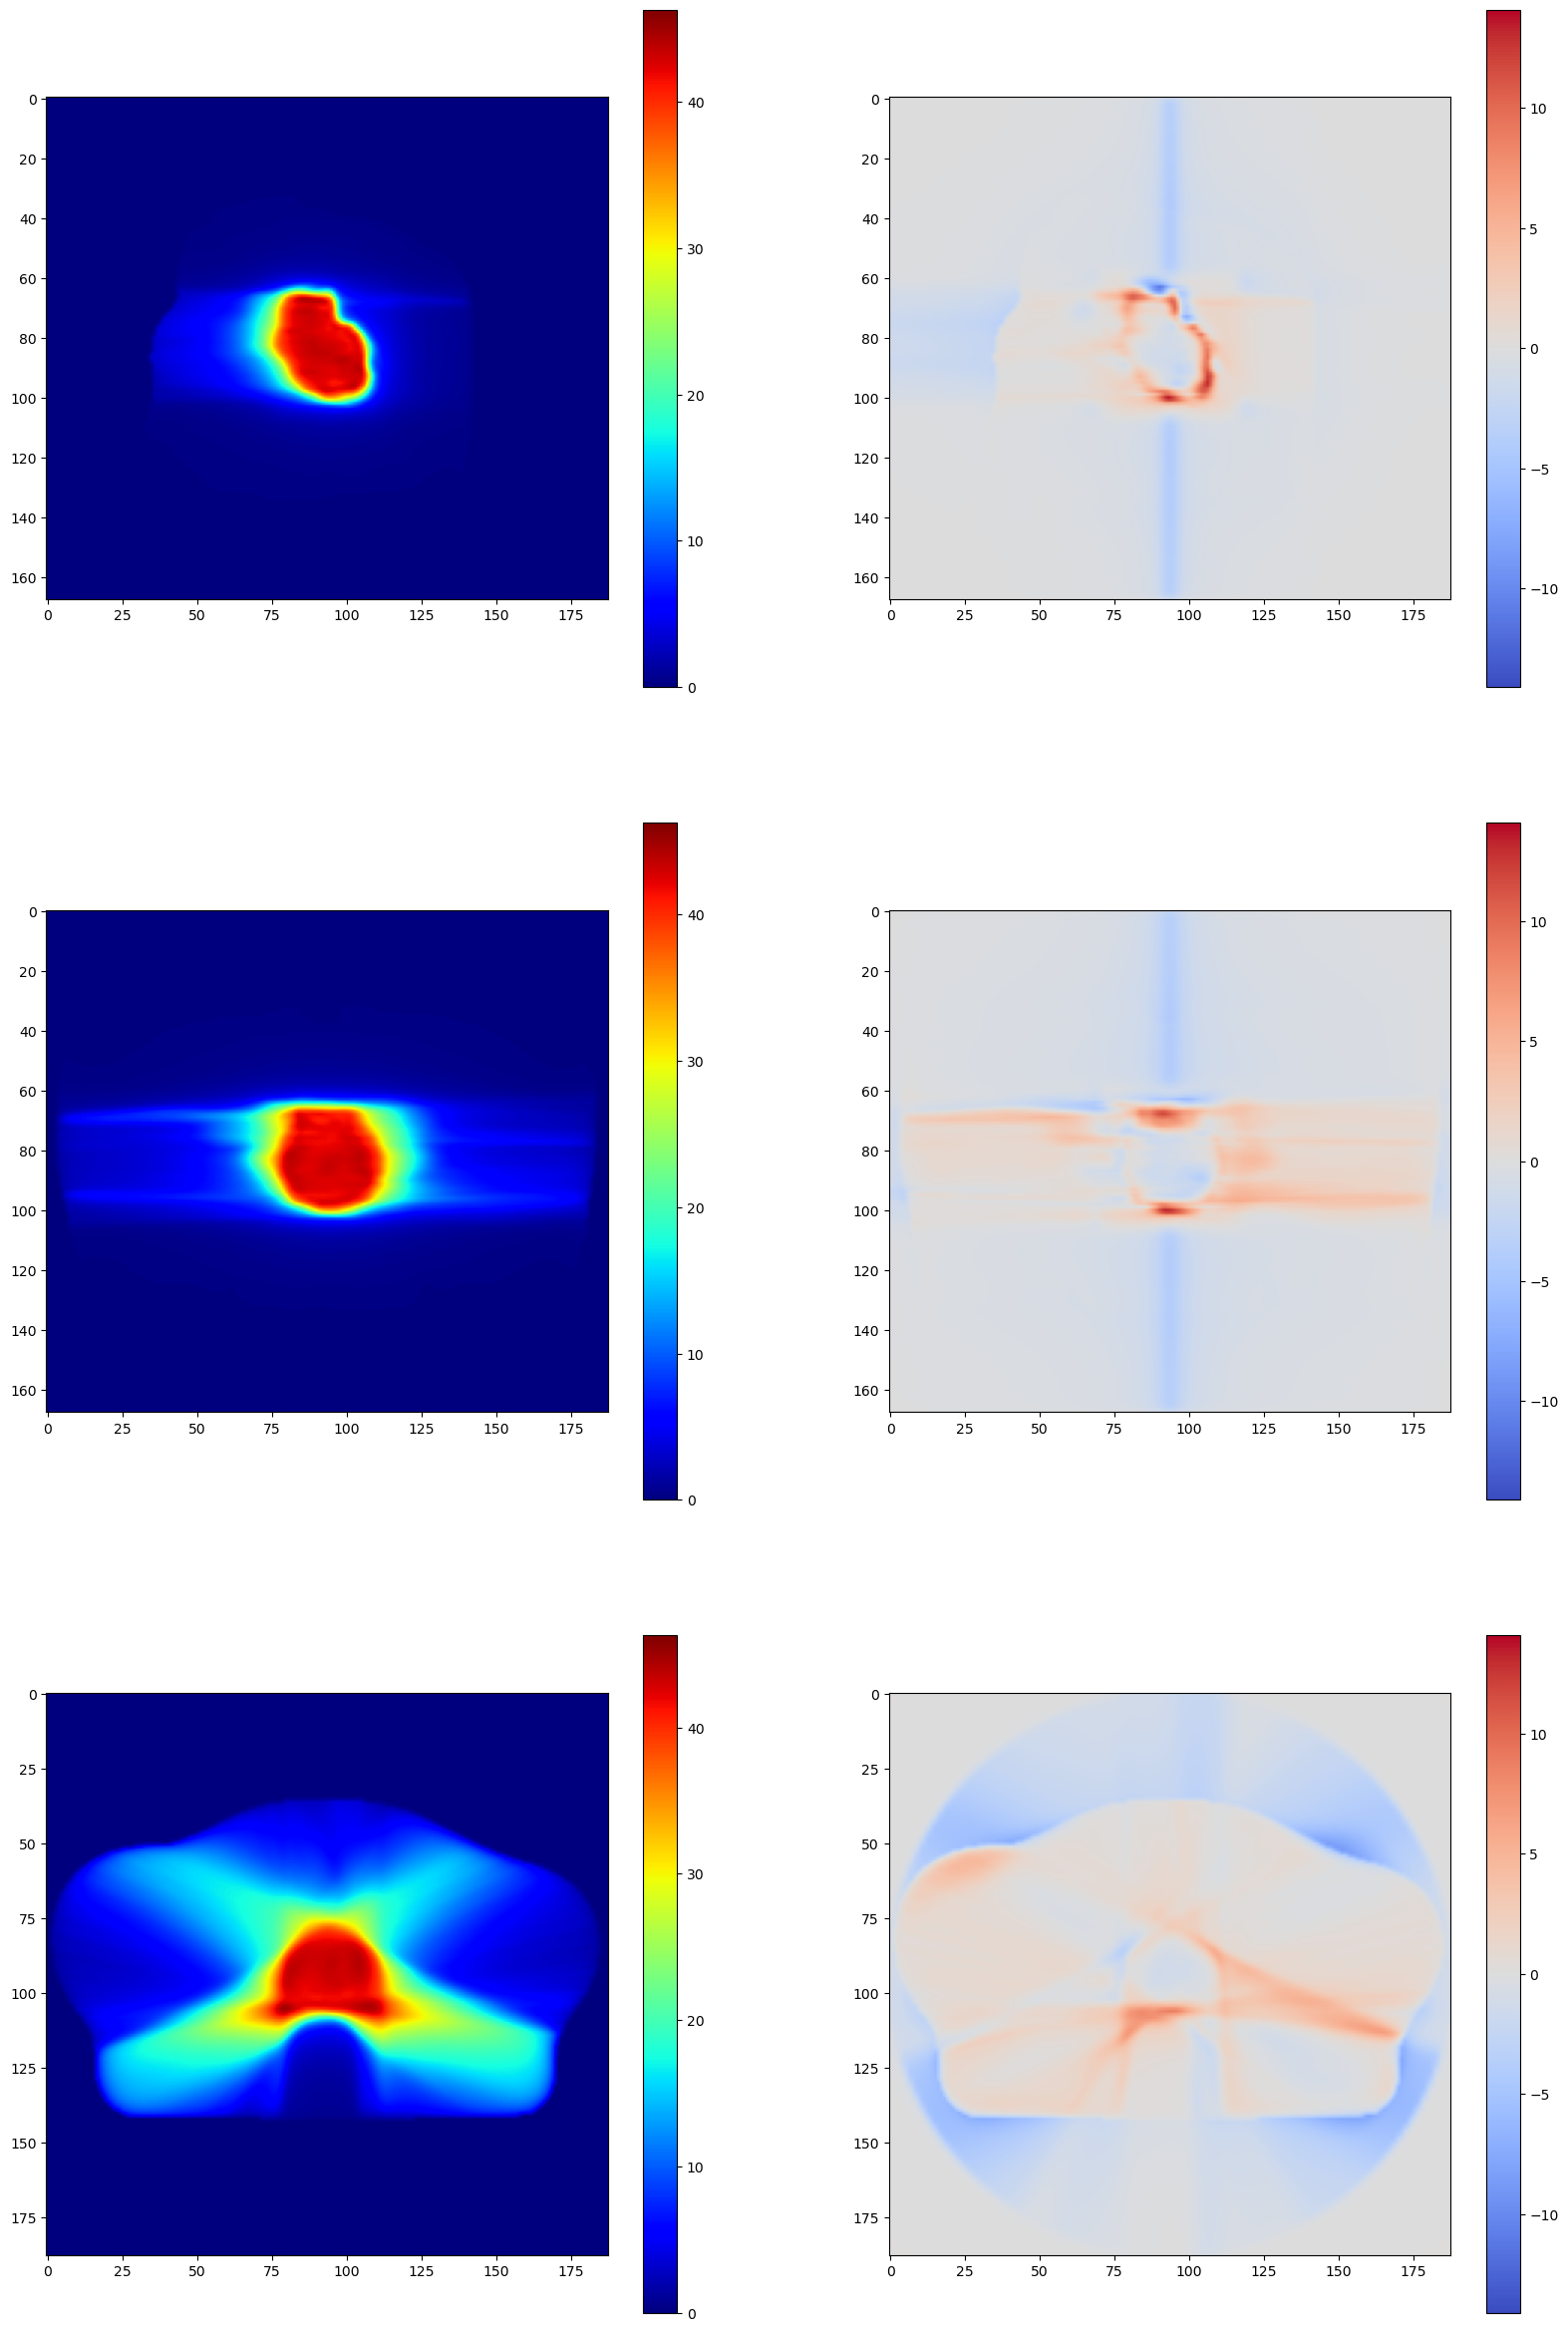

In [10]:
dose_plot = dose_pred
scale = 1.0
pred_max = scale * np.max(np.abs(dose_volume - dose_plot))
pred_min = - pred_max
resampled_ct = ct_image
dose_max = np.max(dose_volume)
alpha = 1.0
plt.figure(figsize=(20, 30))
plt.subplot(321)
# plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(322)
# plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2] - dose_plot[0, :, :, ct_shape[2] // 2], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(323)
# plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_volume[:, ct_shape[1] // 2, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(324)
# plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_volume[:, ct_shape[1] // 2, :] - dose_plot[0, :, ct_shape[1] // 2, :], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(325)
# plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_volume[ct_shape[0] // 2, :, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(326)
# plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_volume[ct_shape[0] // 2, :, :] - dose_plot[0, ct_shape[0] // 2, :, :], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.show()